In [1]:
import os
import glob
import sys
from datetime import datetime
import matplotlib.pyplot as plt
import random
import cv2
import wandb
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Union
from dataclasses import dataclass, asdict
import math

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Number of available cpu: {os.cpu_count()}')

Using device: cuda
Number of available cpu: 4


In [2]:
!pip install tqdm
!pip install albumentations

# Data Pipeline

In [3]:
# Standard library imports
import os
import json
import time
import random
import math
from dataclasses import dataclass
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Optional

# Third-party imports
import numpy as np
import torch
import albumentations as A
import cv2
from PIL import Image, ImageOps
from tqdm.auto import tqdm

# PyTorch data utilities
from torch.utils.data import Dataset, DataLoader

# Global constants...
TARGET_CATEGORIES = [
    "10_dress",
    "8_skirt",
    "43_ruffle",
    "1_top__t_shirt__sweatshirt",
    "0_shirt__blouse",
    "4_jacket",
    "9_coat",
    "2_sweater",
    "3_cardigan",
    "5_vest",
    "6_pants",
    "7_shorts",
]
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


### 1) Pipeline Configuration
Define tunable configuration for dataset paths, target categories, and sketch sampling ratios.

In [4]:

@dataclass
class PipelineConfig:
    """Configuration object for paired sketch-real samples."""

    real_root: str
    sketch_roots: Dict[str, str]
    categories: Tuple[str, ...] = tuple(TARGET_CATEGORIES)
    sketch_ratios: Dict[str, float] = None
    seed: int = 42

    def __post_init__(self):
        if self.sketch_ratios is None:
            self.sketch_ratios = {"hed": 0.5, "pencil": 0.3, "canny": 0.2}

        ratio_sum = sum(self.sketch_ratios.values())
        if not math.isclose(ratio_sum, 1.0, rel_tol=1e-6):
            raise ValueError(f"Sketch ratios must sum to 1.0, got {ratio_sum}")


### 2) Image Preprocessing Helpers
Prepare utility functions for consistent padding, resizing, and category-wise file indexing.

In [5]:
def list_category_images(root: Path, category: str) -> Dict[str, Path]:
    """Return a mapping from filename stem to image path for one category."""
    category_dir = root / category
    if not category_dir.exists():
        return {}

    return {
        p.stem: p
        for p in category_dir.iterdir()
        if p.suffix.lower() in IMG_EXTENSIONS
    }

### 3) Build Paired Metadata
Scan categories, match real and sketch files by stem, and assign sketch methods using the configured sampling ratios.

In [6]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from pathlib import Path
import json
import math
import random
import time
from collections import Counter







def build_gan_pairs(config: PipelineConfig) -> Tuple[List[dict], dict]:
    """Build paired sketch-real samples."""
    print("\n[1/3] Scanning categories, matching real-sketch files...")
    start_time = time.time()

    real_root = Path(config.real_root)
    sketch_roots = {k: Path(v) for k, v in config.sketch_roots.items()}
    rows: List[dict] = []
    skipped_no_sketch = 0

    for category in tqdm(config.categories, desc="Scanning categories"):
        real_images = list_category_images(real_root, category)
        if not real_images:
            continue

        sketch_index = {
            method: list_category_images(root, category)
            for method, root in sketch_roots.items()
        }

        for stem, real_path in real_images.items():
            candidates = {
                method: sketch_index[method][stem]
                for method in sketch_index
                if stem in sketch_index[method]
            }
            if not candidates:
                skipped_no_sketch += 1
                continue


            rows.append(
                {
                    "category": category,
                    "filename_stem": stem,
                    "real_path": str(real_path),
                    "sketch_candidates": candidates,
                    "available_methods": sorted(candidates.keys()),
                    
                }
            )

    print(f"Matched {len(rows)} pairs. Skipped {skipped_no_sketch} without sketches.")
    print("\n[2/3] Assigning sketch methods using ratio targets...")

    rng = random.Random(config.seed)
    total_found = len(rows)
    methods = list(config.sketch_ratios.keys())
    targets = {m: int(total_found * config.sketch_ratios[m]) for m in methods}
    remaining = dict(targets)

    indices = list(range(total_found))
    rng.shuffle(indices)

    for idx in tqdm(indices, desc="Assigning sketch method"):
        row = rows[idx]
        available = row["available_methods"]
        preferred = [m for m in available if remaining.get(m, 0) > 0]
        method = rng.choice(preferred) if preferred else rng.choice(available)

        row["sketch_method"] = method
        row["sketch_path"] = str(row["sketch_candidates"][method])
        if method in remaining:
            remaining[method] -= 1

    final_rows = [
        {
            "category": r["category"],
            "filename_stem": r["filename_stem"],
            "real_path": r["real_path"],
            "sketch_path": r["sketch_path"],
            "sketch_method": r["sketch_method"],
        }
        for r in rows
    ]

    duration = time.time() - start_time
    print(f"Data preparation completed in {duration:.2f}s.")

    summary = {
        "num_pairs": len(final_rows),
        "sketch_method_counts": dict(Counter(r["sketch_method"] for r in final_rows)),
        "skipped_no_sketch": skipped_no_sketch,
    }
    return final_rows, summary

### 4) Dataset and DataLoader
Define the PyTorch dataset and a reusable DataLoader builder with safe defaults.

In [7]:
# Cell 5
import os
from typing import List, Tuple, Optional
import numpy as np
import torch
import albumentations as A
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class SketchToRealGANDataset(Dataset):
    """PyTorch dataset that loads paired sketch-real images."""

    def __init__(
        self,
        rows: List[dict],
        image_size: int = 256,
        apply_augmentation: bool = False,
        flip_prob: float = 0.5,
        crop_scale: Tuple[float, float] = (0.9, 1.0),
        max_translate_ratio: float = 0.08,
        max_rotation_deg: float = 10.0,
        scale_range: Tuple[float, float] = (0.95, 1.05),
        # Thêm các tham số cho việc làm đứt nét Sketch
        sketch_degrade_prob: float = 0.7,
        degrade_holes_range: Tuple[int, int] = (5, 20),
        degrade_size_range: Tuple[int, int] = (10, 40),
    ):
        self.rows = rows
        self.image_size = image_size
        self.apply_augmentation = apply_augmentation
        
        # --- 1. SPATIAL AUGMENTATION (Áp dụng chung cho cả Real và Sketch để giữ align) ---
        max_shift_percent = max_translate_ratio * 100.0
        self._spatial_augment = A.Compose(
            [
                A.HorizontalFlip(p=flip_prob),
                A.RandomResizedCrop(
                    size=(self.image_size, self.image_size),
                    scale=crop_scale,
                    ratio=(1.0, 1.0),
                    interpolation=cv2.INTER_LINEAR,
                    p=1.0,
                ),
                A.Affine(
                    scale=scale_range,
                    translate_percent={"x": (-max_shift_percent / 100.0, max_shift_percent / 100.0), "y": (-max_shift_percent / 100.0, max_shift_percent / 100.0)},
                    rotate=(-max_rotation_deg, max_rotation_deg),
                    interpolation=cv2.INTER_LINEAR,
                    border_mode=cv2.BORDER_CONSTANT,
                    fill=(255, 255, 255),
                    p=1.0,
                ),
            ],
            additional_targets={"real": "image"},
        )

        # --- 2. SKETCH DEGRADATION (Chỉ áp dụng cho Sketch để ép model học nội suy) ---
        self._sketch_only_augment = A.Compose(
            [
                # Làm đứt nét bằng cách xóa ngẫu nhiên các ô vuông (tô màu trắng)
                A.CoarseDropout(
                    max_holes=degrade_holes_range[1],
                    min_holes=degrade_holes_range[0],
                    max_height=degrade_size_range[1],
                    max_width=degrade_size_range[1],
                    min_height=degrade_size_range[0],
                    min_width=degrade_size_range[0],
                    fill=(255, 255, 255), 
                    p=sketch_degrade_prob
                ),

            ]
        )

    def _load_img(self, path: str) -> np.ndarray:
        img_bgr = cv2.imread(path)
        if img_bgr is None:
            raise ValueError(f"Could not load image: {path}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
        return img_resized

    def _apply_spatial_augment_pair(
        self,
        sketch_img: np.ndarray,
        real_img: np.ndarray,
    ) -> Tuple[np.ndarray, np.ndarray]:
        transformed = self._spatial_augment(image=sketch_img, real=real_img)
        return transformed["image"], transformed["real"]

    def _to_tensor(self, img: np.ndarray) -> torch.Tensor:
        arr = img.astype(np.float32) / 127.5 - 1.0
        return torch.from_numpy(arr).permute(2, 0, 1)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        sketch_img = self._load_img(row["sketch_path"])
        real_img = self._load_img(row["real_path"])
        
        if self.apply_augmentation:
            # Bước 1: Augment không gian cho cả 2 ảnh để giữ sự đồng nhất
            sketch_img, real_img = self._apply_spatial_augment_pair(sketch_img, real_img)
            
            # Bước 2: Chỉ làm hỏng (degrade) ảnh Sketch
            sketch_img = self._sketch_only_augment(image=sketch_img)["image"]

        return {
            "sketch": self._to_tensor(sketch_img),
            "real": self._to_tensor(real_img),
            "filename_stem": row["filename_stem"],
        }


def build_gan_dataloader(
    rows: List[dict],
    batch_size: int = 16,
    image_size: int = 256,
    shuffle: bool = True,
    num_workers: Optional[int] = None,
    apply_augmentation: bool = False,
    sketch_degrade_prob: float = 0.7, 
) -> DataLoader:
    """Build a DataLoader from paired metadata rows."""
    if num_workers is None:
        num_workers = 4

    dataset = SketchToRealGANDataset(
        rows=rows,
        image_size=image_size,
        apply_augmentation=apply_augmentation,
        sketch_degrade_prob=sketch_degrade_prob,
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

### 5) Run Pipeline and Quick Verification
Instantiate config, build pairs, create DataLoader, and run a short dry-run to validate input throughput.

In [8]:
print("Starting data pipeline...")

PIPE_CFG = PipelineConfig(
    real_root="/kaggle/input/datasets/vunhuduc/train-fashion-no-blur/(1)_images_filtered_no_bg",
    sketch_roots={
        "hed": "/kaggle/input/datasets/vunhuduc/train-sketch/fashion_category_filtered/(2)_sketch_hed",
        "pencil": "/kaggle/input/datasets/vunhuduc/train-sketch/fashion_category_filtered/(2)_sketch_pencil",
        "canny": "/kaggle/input/datasets/vunhuduc/train-sketch/fashion_category_filtered/(2)_sketch_canny",
    },
)

# Step 1: Build aligned sketch-real metadata.
gan_rows, gan_summary = build_gan_pairs(PIPE_CFG)

print("\n" + "=" * 30)
print("PIPELINE SUMMARY:")
print(f"- Total paired samples: {gan_summary['num_pairs']}")
for method, count in gan_summary["sketch_method_counts"].items():
    print(f"  + {method}: {count} samples")
print("=" * 30)

print("\n[3/3] Initializing DataLoader...")
gan_loader = build_gan_dataloader(
    rows=gan_rows,
    batch_size=8,
    image_size=256,
    shuffle=True,
    apply_augmentation=True,
)
print(f"DataLoader ready. Total batches: {len(gan_loader)}")

print("\nRunning dry-run for first 10 batches...")
for i, batch in enumerate(tqdm(gan_loader, total=10)):
    assert batch['sketch'].shape[1:] == (3, 256, 256)
    assert batch['real'].shape[1:] == (3, 256, 256)
    if i >= 9:
        break

print("\nPipeline is ready for training with sketch + z inputs.")

Starting data pipeline...

[1/3] Scanning categories, matching real-sketch files...


Scanning categories:   0%|          | 0/12 [00:00<?, ?it/s]

Matched 66294 pairs. Skipped 0 without sketches.

[2/3] Assigning sketch methods using ratio targets...


Assigning sketch method:   0%|          | 0/66294 [00:00<?, ?it/s]

Data preparation completed in 6.00s.

PIPELINE SUMMARY:
- Total paired samples: 66294
  + pencil: 19888 samples
  + canny: 13259 samples
  + hed: 33147 samples

[3/3] Initializing DataLoader...
DataLoader ready. Total batches: 8287

Running dry-run for first 10 batches...


/tmp/ipykernel_58/1710875359.py:62: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If

  0%|          | 0/10 [00:00<?, ?it/s]


Pipeline is ready for training with sketch + z inputs.


/tmp/ipykernel_58/1710875359.py:62: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


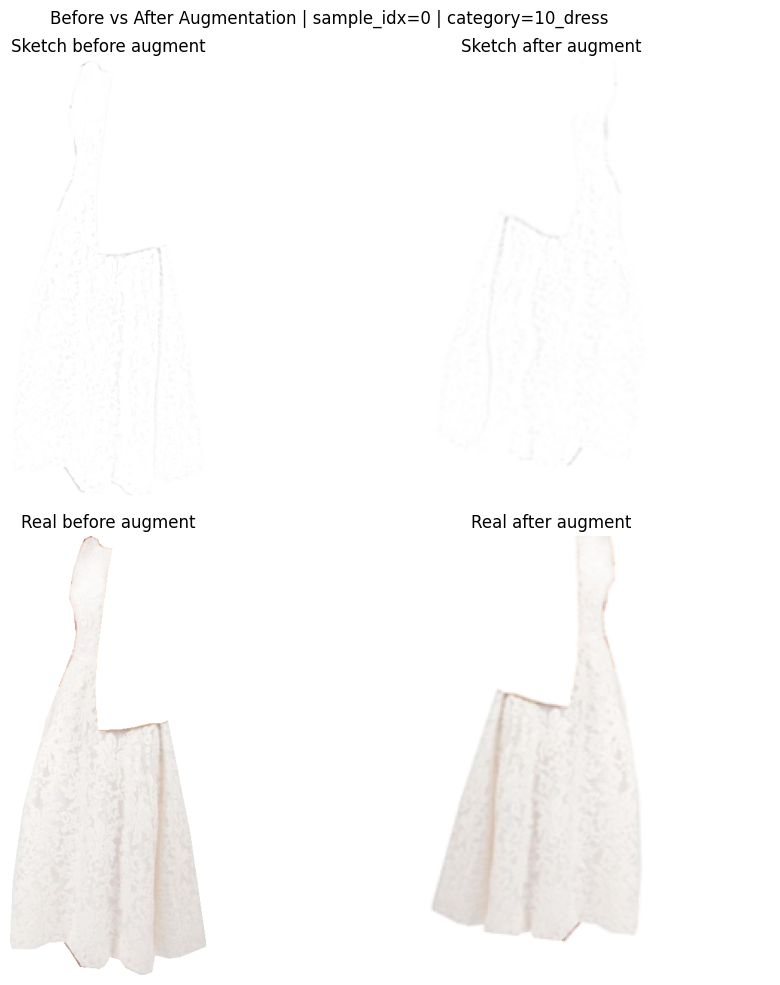

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path


def pil_to_uint8(image: Image.Image) -> np.ndarray:
    return np.asarray(image.convert("RGB"), dtype=np.uint8)


def tensor_to_uint8_img(tensor):
    """Convert a normalized CHW tensor in [-1, 1] to a displayable uint8 image."""
    image = tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = ((image + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    return image


def show_before_after_augment(sample_idx: int = 0):
    """Show images before and after augmentation for both sketch and real pairs."""
    if "gan_rows" not in globals() or len(gan_rows) == 0:
        print("gan_rows chưa có dữ liệu. Hãy chạy cell tạo DataLoader trước.")
        return

    if "SketchToRealGANDataset" not in globals():
        print("Dataset class chưa sẵn sàng. Hãy chạy cell Data Pipeline trước.")
        return

    sample = gan_rows[sample_idx]
    before_sketch = pil_to_uint8(Image.open(sample["sketch_path"]).convert("RGB"))
    before_real = pil_to_uint8(Image.open(sample["real_path"]).convert("RGB"))

    preview_dataset = SketchToRealGANDataset(
        rows=[sample],
        image_size=256,
        apply_augmentation=True,
    )
    aug_item = preview_dataset[0]
    after_sketch = tensor_to_uint8_img(aug_item["sketch"])
    after_real = tensor_to_uint8_img(aug_item["real"])

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    axes[0, 0].imshow(before_sketch)
    axes[0, 0].set_title("Sketch before augment")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(after_sketch)
    axes[0, 1].set_title("Sketch after augment")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(before_real)
    axes[1, 0].set_title("Real before augment")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(after_real)
    axes[1, 1].set_title("Real after augment")
    axes[1, 1].axis("off")

    plt.suptitle(f"Before vs After Augmentation | sample_idx={sample_idx} | category={sample['category']}")
    plt.tight_layout()
    plt.show()


show_before_after_augment(sample_idx=0)

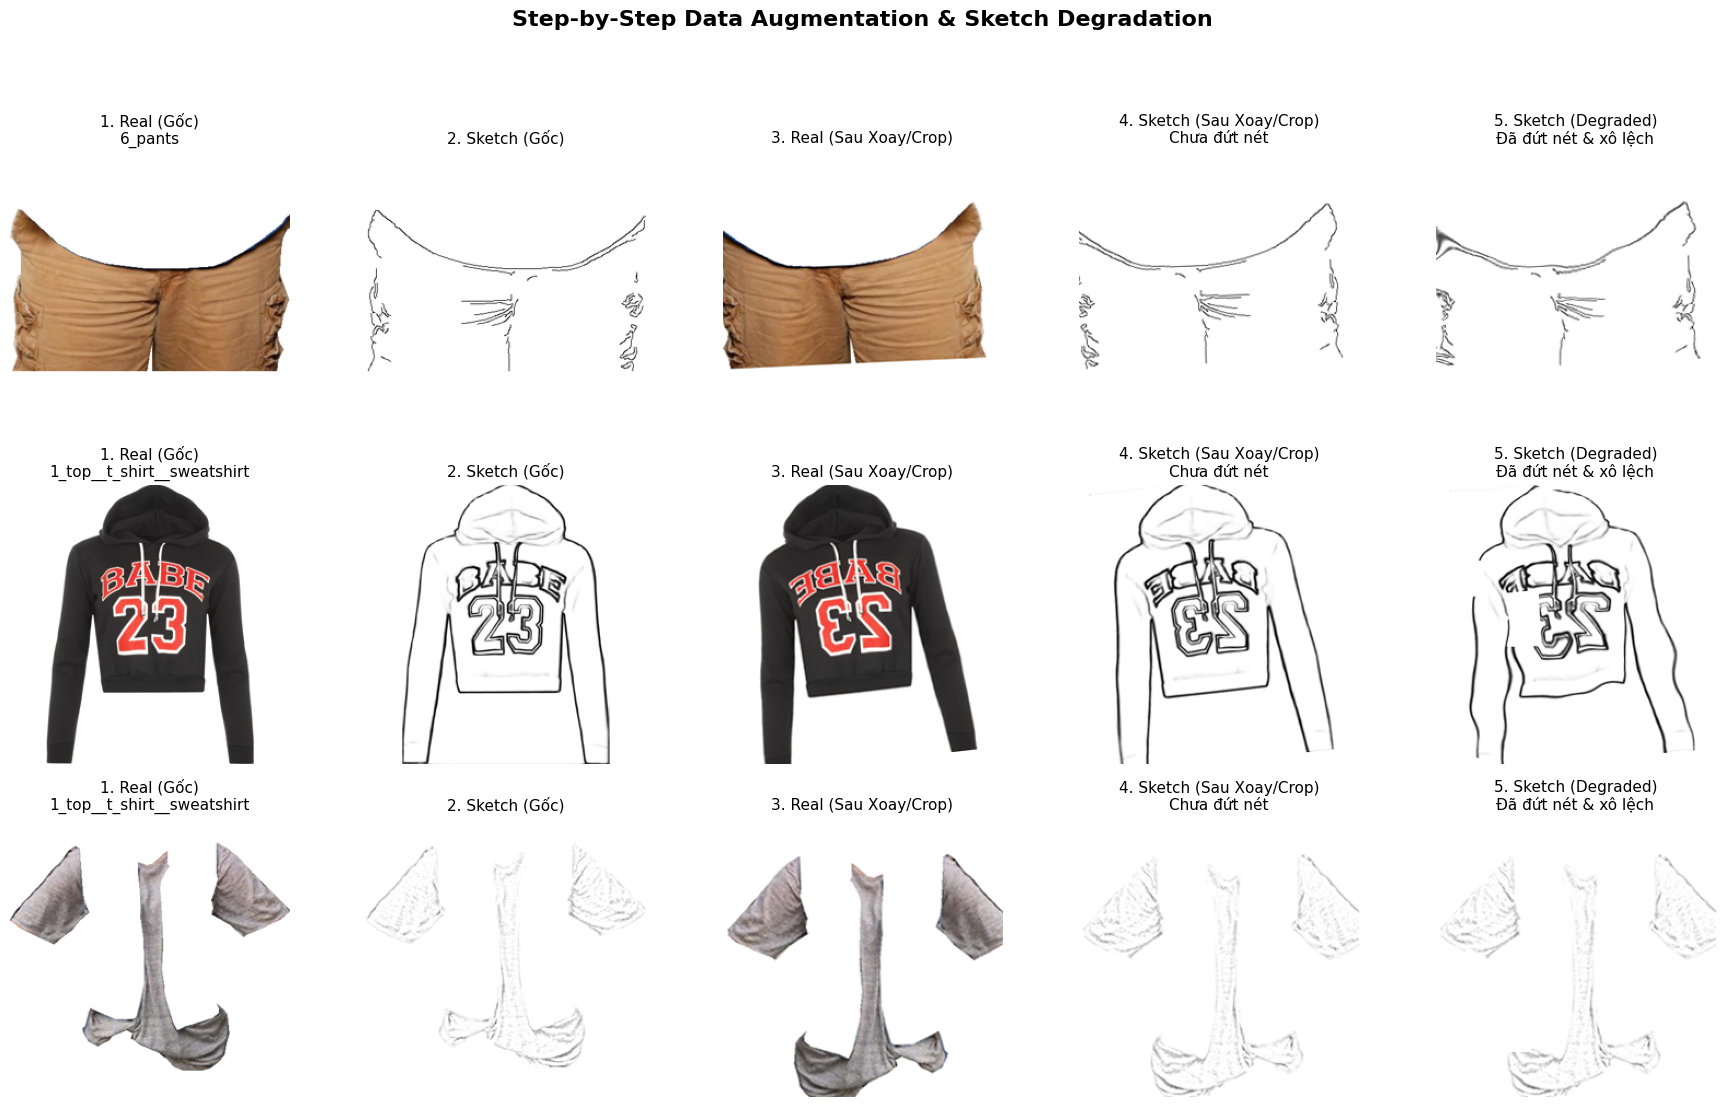

In [10]:
# Cell 8
import matplotlib.pyplot as plt
import numpy as np
import random

def visualize_degradation_pipeline(dataset: SketchToRealGANDataset, num_samples: int = 3):
    """
    Trực quan hóa từng bước của quá trình Data Augmentation:
    Original -> Spatial Transform (cả 2) -> Degrade (chỉ Sketch)
    """
    if len(dataset) == 0:
        print("Dataset trống!")
        return

    # Lấy ngẫu nhiên các chỉ số
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    # Kích thước lưới: num_samples hàng, 5 cột (Real gốc, Sketch gốc, Real Spatial, Sketch Spatial, Sketch Degraded)
    fig, axes = plt.subplots(len(indices), 5, figsize=(18, 3.5 * len(indices)))
    
    # Xử lý trường hợp chỉ có 1 sample (axes sẽ là mảng 1D)
    if len(indices) == 1:
        axes = [axes]

    for i, idx in enumerate(indices):
        row = dataset.rows[idx]
        
        # 1. Load ảnh gốc (đã pad/resize)
        sketch_raw = dataset._load_img(row["sketch_path"])
        real_raw = dataset._load_img(row["real_path"])
        
        # 2. Áp dụng Spatial Augmentation (biến dạng không gian, áp dụng cho cả 2)
        transformed_spatial = dataset._spatial_augment(image=sketch_raw, real=real_raw)
        sketch_spatial = transformed_spatial["image"]
        real_spatial = transformed_spatial["real"]
        
        # 3. Áp dụng Sketch-only Augmentation (chỉ làm đứt nét/méo trên sketch)
        transformed_degrade = dataset._sketch_only_augment(image=sketch_spatial)
        sketch_degraded = transformed_degrade["image"]
        
        # --- Bắt đầu vẽ ---
        panels = [
            (real_raw, f"1. Real (Gốc)\n{row['category']}"),
            (sketch_raw, "2. Sketch (Gốc)"),
            (real_spatial, "3. Real (Sau Xoay/Crop)"),
            (sketch_spatial, "4. Sketch (Sau Xoay/Crop)\nChưa đứt nét"),
            (sketch_degraded, "5. Sketch (Degraded)\nĐã đứt nét & xô lệch"),
        ]
        
        for col, (img, title) in enumerate(panels):
            ax = axes[i][col]
            ax.imshow(img)
            ax.set_title(title, fontsize=11)
            ax.axis("off")
            
            # Thêm viền đỏ cho ảnh Degraded để dễ nhận biết
            if col == 4:
                for spine in ax.spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(2)
                    spine.set_visible(True)

    plt.suptitle("Step-by-Step Data Augmentation & Sketch Degradation", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Lấy dataset từ dataloader đã tạo ở Cell 6 (hoặc khởi tạo mới)
# Đảm bảo bạn đã chạy Cell 5 (mới) và Cell 6 trước khi chạy code này
if 'gan_loader' in globals():
    my_dataset = gan_loader.dataset
    visualize_degradation_pipeline(my_dataset, num_samples=3)
else:
    print("Vui lòng khởi tạo 'gan_loader' trước.")

/tmp/ipykernel_58/1710875359.py:62: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


Hiển thị 4 mẫu | số cột: 9


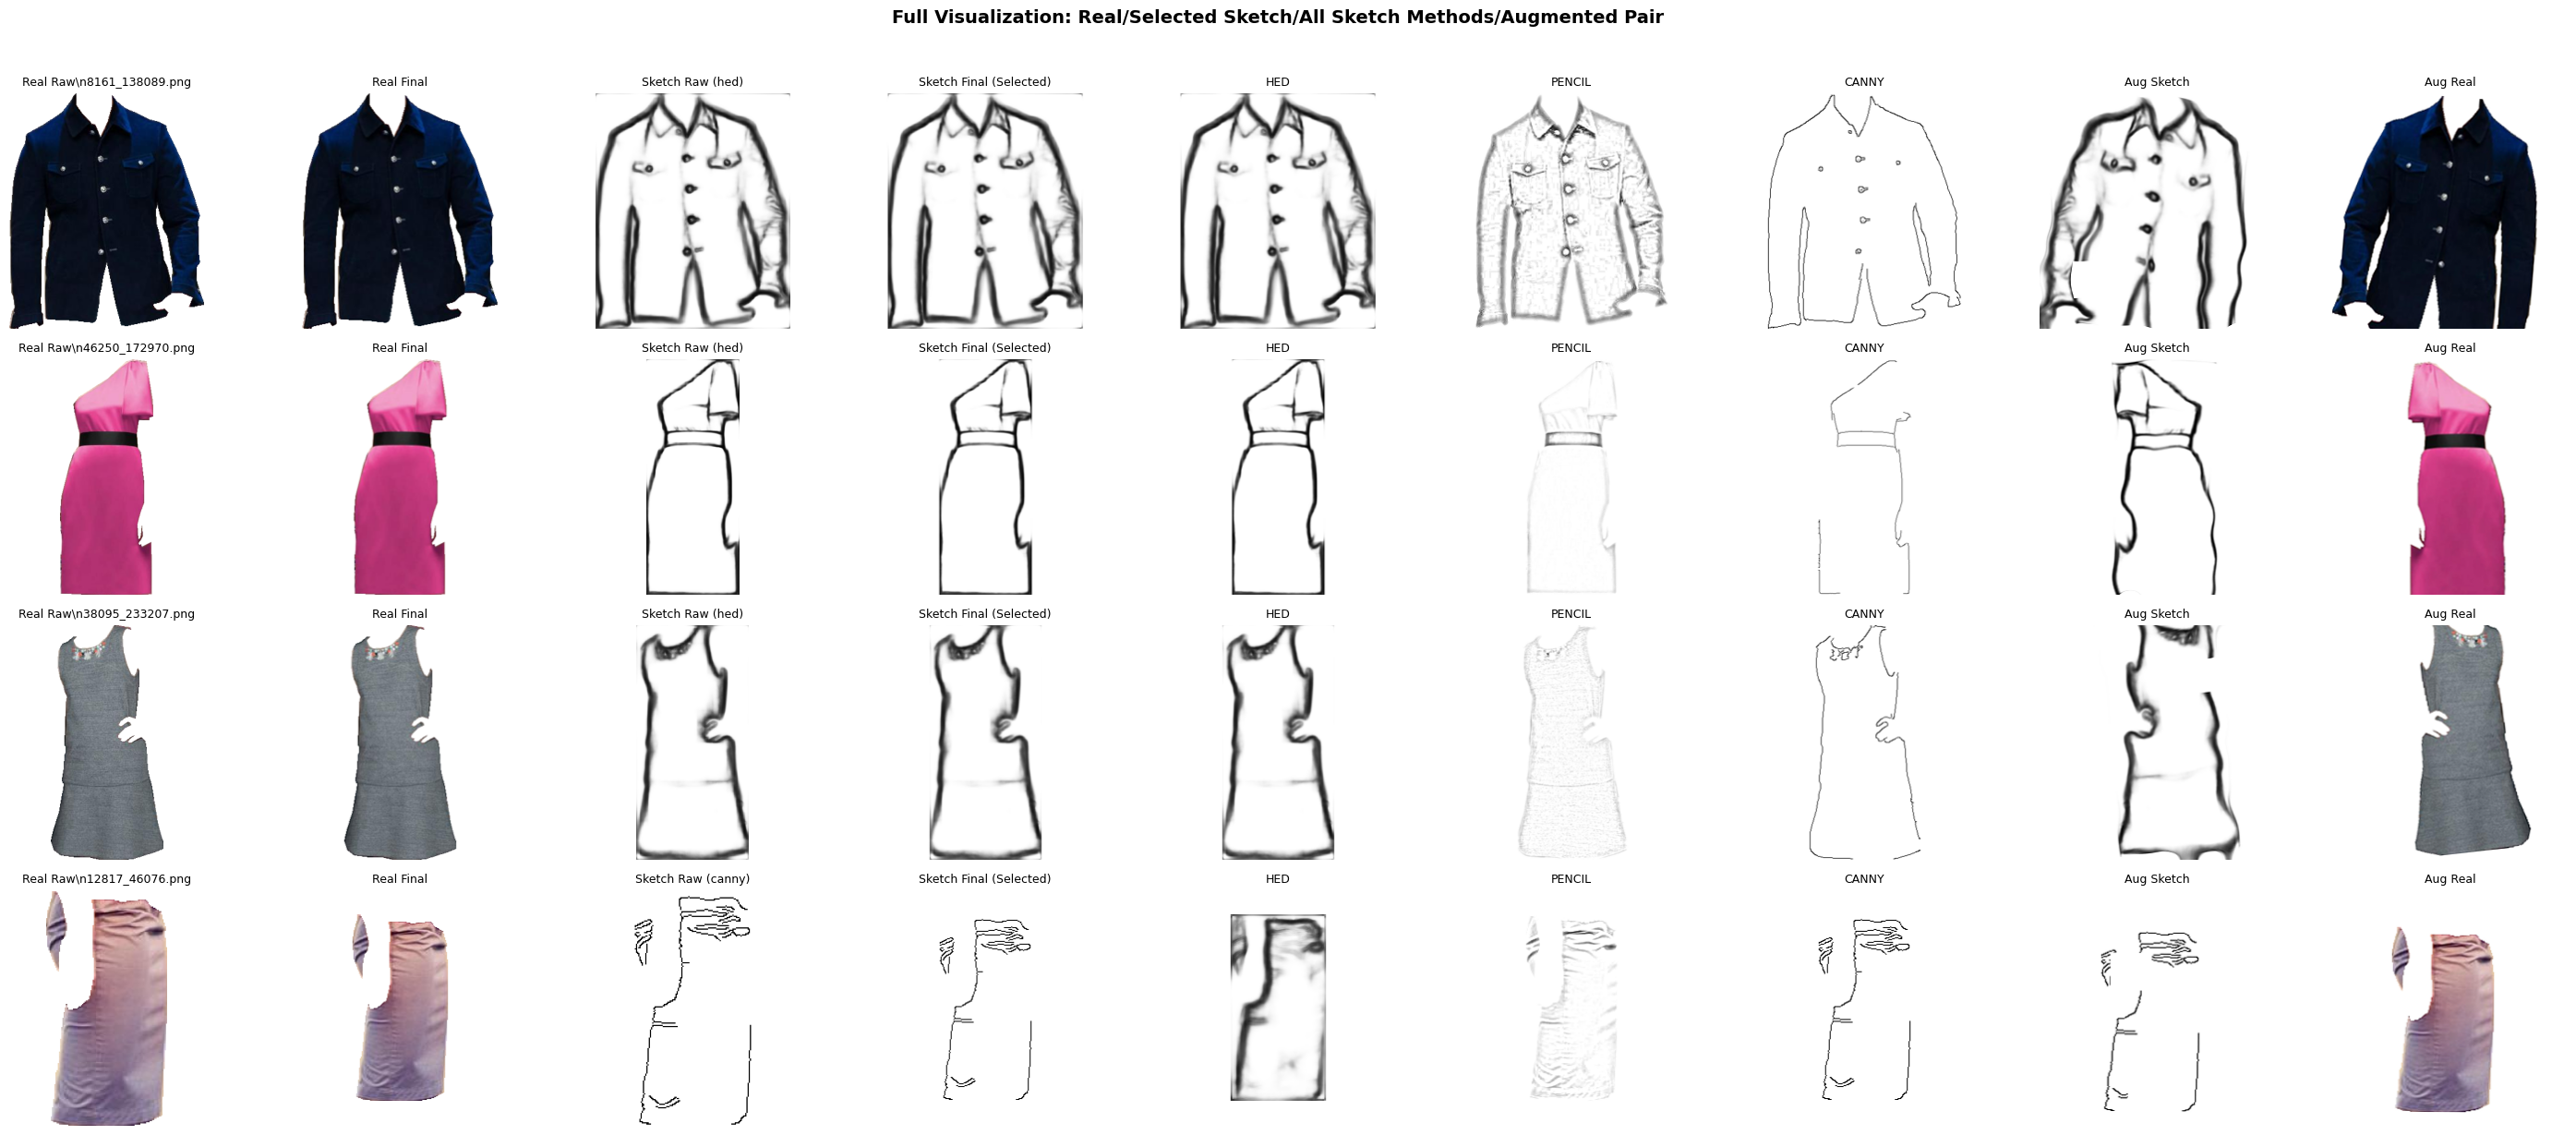

In [11]:
import matplotlib.pyplot as plt
import random
from pathlib import Path


def preprocess_preview(path: str, target_size: int = 256):
    """Return raw, smart-padded, and resized versions of one image."""
    with Image.open(path) as src_img:
        raw = src_img.convert("RGB")

    w, h = raw.size
    canvas_side = max(w, h, target_size)
    pad_left = (canvas_side - w) // 2
    pad_top = (canvas_side - h) // 2
    pad_right = canvas_side - w - pad_left
    pad_bottom = canvas_side - h - pad_top

    padded = ImageOps.expand(
        raw,
        border=(pad_left, pad_top, pad_right, pad_bottom),
        fill=(255, 255, 255),
    )
    resized = padded.resize((target_size, target_size), Image.BICUBIC)
    return raw, padded, resized


def find_sketch_by_method(row: dict, method: str):
    """Find sketch image path for a specific method using pipeline config roots."""
    if "PIPE_CFG" not in globals():
        return None

    root = PIPE_CFG.sketch_roots.get(method)
    if root is None:
        return None

    category = row["category"]
    stem = row["filename_stem"]
    method_dir = Path(root) / category
    if not method_dir.exists():
        return None

    for ext in IMG_EXTENSIONS:
        candidate = method_dir / f"{stem}{ext}"
        if candidate.exists():
            return str(candidate)
    return None


def tensor_to_uint8_img(t: torch.Tensor) -> np.ndarray:
    """Convert CHW tensor in [-1, 1] to HWC uint8 image."""
    arr = t.detach().cpu().permute(1, 2, 0).numpy()
    arr = ((arr + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    return arr


def visualize_full_samples(num_samples: int = 3, image_size: int = 256):
    """Visualize full sample information, including all sketch methods and augment result."""
    if "gan_rows" not in globals() or len(gan_rows) == 0:
        print("'gan_rows' chưa có dữ liệu. Hãy chạy Cell 15 trước.")
        return

    if "SketchToRealGANDataset" not in globals():
        print("Dataset class chưa sẵn sàng. Hãy chạy Cell 13 trước.")
        return

    sample_rows = random.sample(gan_rows, k=min(num_samples, len(gan_rows)))

    # Methods come from current config to guarantee complete per-method view.
    method_list = list(PIPE_CFG.sketch_roots.keys()) if "PIPE_CFG" in globals() else []

    # Build one augmented dataset instance to preview synchronized spatial augmentation.
    preview_dataset = SketchToRealGANDataset(
        rows=sample_rows,
        image_size=image_size,
        apply_augmentation=True,
    )

    # Columns: Real(raw/final), Selected Sketch(raw/final), each method final, augmented pair.
    n_cols = 4 + len(method_list) + 2
    fig, axes = plt.subplots(len(sample_rows), n_cols, figsize=(3.2 * n_cols, 3.0 * len(sample_rows)))
    if len(sample_rows) == 1:
        axes = [axes]

    print(f"Hiển thị {len(sample_rows)} mẫu | số cột: {n_cols}")

    for r, row in enumerate(sample_rows):
        # Real + selected sketch processing previews.
        real_raw, _, real_final = preprocess_preview(row["real_path"], target_size=image_size)
        sketch_raw, _, sketch_final = preprocess_preview(row["sketch_path"], target_size=image_size)

        # Augmented aligned pair preview.
        aug_item = preview_dataset[r]
        aug_sketch = tensor_to_uint8_img(aug_item["sketch"])
        aug_real = tensor_to_uint8_img(aug_item["real"])

        panels = [
            (real_raw, f"Real Raw\\n{Path(row['real_path']).name}"),
            (real_final, "Real Final"),
            (sketch_raw, f"Sketch Raw ({row['sketch_method']})"),
            (sketch_final, "Sketch Final (Selected)"),
        ]

        # Add each sketch type (hed/pencil/canny/...) for full comparison.
        for method in method_list:
            m_path = find_sketch_by_method(row, method)
            if m_path is None:
                blank = np.full((image_size, image_size, 3), 255, dtype=np.uint8)
                panels.append((blank, f"{method.upper()} (missing)"))
            else:
                _, _, m_final = preprocess_preview(m_path, target_size=image_size)
                panels.append((m_final, f"{method.upper()}"))

        panels.append((aug_sketch, "Aug Sketch"))
        panels.append((aug_real, "Aug Real"))

        for c, (img, title) in enumerate(panels):
            axes[r][c].imshow(img)
            axes[r][c].set_title(title, fontsize=9)
            axes[r][c].axis("off")

        # Write sample-level text at the first panel for quick traceability.
        axes[r][0].set_ylabel(
            f"Sample {r + 1}\\ncat: {row['category']}",
            rotation=90,
            fontsize=9,
            labelpad=10,
        )

    plt.suptitle(
        "Full Visualization: Real/Selected Sketch/All Sketch Methods/Augmented Pair",
        y=1.02,
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


# Run visualization
visualize_full_samples(num_samples=4, image_size=256)

# Mobile Sketch2Image (MS2I) Network Implementation

## Common Blocks

## MUNIT Architecture Components

This section contains the MUNIT building blocks: ResBlocks, Encoders, Decoders.


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, dim, use_adain=False):
        super().__init__()
        self.use_adain = use_adain
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, padding_mode='reflect')
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=3, padding=1, padding_mode='reflect')
        
        if not use_adain:
            self.norm1 = nn.InstanceNorm2d(dim, affine=True)
            self.norm2 = nn.InstanceNorm2d(dim, affine=True)
            
    def forward(self, x, adain_params=None):
        out = self.conv1(x)
        if self.use_adain:
            out = self.adain(out, adain_params[:, :out.size(1)*2])
        else:
            out = self.norm1(out)
        out = F.relu(out)
        
        out = self.conv2(out)
        if self.use_adain:
            out = self.adain(out, adain_params[:, out.size(1)*2:])
        else:
            out = self.norm2(out)
            
        return x + out

    def adain(self, x, params):
        # params is (B, 2*C)
        b, c = x.size(0), x.size(1)
        mean, std = params[:, :c].view(b, c, 1, 1), params[:, c:].view(b, c, 1, 1)
        
        # Compute statistics in float32 to prevent FP16 overflow under AMP
        x_32 = x.float()
        x_mean = x_32.mean(dim=[2, 3], keepdim=True)
        x_std = x_32.std(dim=[2, 3], keepdim=True) + 1e-5
        x_norm = (x_32 - x_mean) / x_std
        return (x_norm.to(x.dtype) * std) + mean

In [13]:
class ContentEncoder(nn.Module):
    def __init__(self, in_channels=3, dim=64, n_downsample=2, n_res=4):
        super().__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_channels, dim, kernel_size=7),
            nn.InstanceNorm2d(dim, affine=True),
            nn.ReLU(inplace=True)
        ]
        
        # Downsampling
        for i in range(n_downsample):
            layers += [
                nn.Conv2d(dim, dim * 2, kernel_size=4, stride=2, padding=1),
                nn.InstanceNorm2d(dim * 2, affine=True),
                nn.ReLU(inplace=True)
            ]
            dim *= 2
            
        # Residual blocks
        for i in range(n_res):
            layers += [ResBlock(dim)]
            
        self.model = nn.Sequential(*layers)
        self.output_dim = dim
        
    def forward(self, x):
        return self.model(x)

class StyleEncoder(nn.Module):
    def __init__(self, in_channels=3, dim=64, n_downsample=4, style_dim=8):
        super().__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_channels, dim, kernel_size=7),
            nn.ReLU(inplace=True)
        ]
        
        for i in range(2):
            layers += [
                nn.Conv2d(dim, dim * 2, kernel_size=4, stride=2, padding=1),
                nn.ReLU(inplace=True)
            ]
            dim *= 2
            
        for i in range(n_downsample - 2):
            layers += [
                nn.Conv2d(dim, dim, kernel_size=4, stride=2, padding=1),
                nn.ReLU(inplace=True)
            ]
            
        self.model = nn.Sequential(*layers)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(dim, style_dim)
        
    def forward(self, x):
        x = self.model(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.fc(x)


In [21]:
class Decoder(nn.Module):
    def __init__(self, out_channels=3, dim=256, n_up=2, n_res=4, style_dim=8):
        super().__init__()
        self.n_res = n_res
        
        # MLP for AdaIN parameters
        # Total parameters needed: 2 (mean, std) * dim * 2 (conv layers per resblock) * n_res
        total_adain_params = 2 * dim * 2 * n_res
        self.mlp = nn.Sequential(
            nn.Linear(style_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, total_adain_params)
        )
        
        # ResBlocks with AdaIN
        self.res_blocks = nn.ModuleList([ResBlock(dim, use_adain=True) for _ in range(n_res)])
        
        # Upsampling
        layers = []
        for i in range(n_up):
            layers += [
                nn.Upsample(scale_factor=2, mode='nearest'),
                nn.ReflectionPad2d(2),
                nn.Conv2d(dim, dim // 2, kernel_size=5),
                nn.InstanceNorm2d(dim // 2, affine=True),
                nn.ReLU(inplace=True)
            ]
            dim //= 2
            
        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(dim, out_channels, kernel_size=7),
            nn.Tanh()
        ]
        self.up_model = nn.Sequential(*layers)
        self.dim = 256 # internal dimension for AdaIN param slicing
        
    def forward(self, content, style):
            
        adain_params = self.mlp(style)
        
        x = content
        params_per_block = 4 * self.dim  # 2 layers * 2 params (mean, std) * dim
        for i, res_block in enumerate(self.res_blocks):
            p = adain_params[:, i*params_per_block : (i+1)*params_per_block]
            x = res_block(x, p)
            
        return self.up_model(x)


In [22]:
class MUNIT(nn.Module):
    def __init__(self, style_dim=8):
        super().__init__()
        self.style_dim = style_dim
        
        # Domain A: Sketch
        self.enc_c_a = ContentEncoder(in_channels=3)
        self.enc_s_a = StyleEncoder(in_channels=3, style_dim=style_dim)
        self.dec_a = Decoder(out_channels=3, style_dim=style_dim) 
        
        # Domain B: Real Image
        self.enc_c_b = ContentEncoder(in_channels=3)
        self.enc_s_b = StyleEncoder(in_channels=3, style_dim=style_dim)
        self.dec_b = Decoder(out_channels=3, style_dim=style_dim)
        
    def forward(self):
        pass
        
    def encode(self, x, domain):
        if domain == 'A':
            return self.enc_c_a(x), self.enc_s_a(x)
        else:
            return self.enc_c_b(x), self.enc_s_b(x)
            
    def decode(self, c, s, domain):
        if domain == 'A':
            return self.dec_a(c, s)
        else:
            return self.dec_b(c, s)


## Discriminators

Multi-scale discriminators for Domain A and Domain B.


In [23]:
class MultiScaleDiscriminator(nn.Module):
    def __init__(self, in_channels=3, n_scales=3, dim=64):
        super().__init__()
        self.n_scales = n_scales
        self.downsample = nn.AvgPool2d(3, stride=2, padding=[1, 1], count_include_pad=False)
        self.models = nn.ModuleList()
        
        for _ in range(n_scales):
            self.models.append(self._make_net(in_channels, dim))
            
    def _make_net(self, in_channels, dim):
        layers = [
            nn.Conv2d(in_channels, dim, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(dim, dim * 2, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(dim * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(dim * 2, dim * 4, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(dim * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(dim * 4, dim * 8, kernel_size=4, stride=1, padding=1),
            nn.InstanceNorm2d(dim * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(dim * 8, 1, kernel_size=4, stride=1, padding=1)
        ]
        return nn.Sequential(*layers)
        
    def forward(self, x):
        outputs = []
        for model in self.models:
            outputs.append(model(x))
            x = self.downsample(x)
        return outputs
        
    def compute_loss(self, x, label):
        loss = 0
        outputs = self.forward(x)
        for out in outputs:
            loss += F.mse_loss(out, torch.full_like(out, label))
        return loss


## Training Configuration and Utilities


In [ ]:
import csv
import json
import time
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import defaultdict
from torch.amp import autocast, GradScaler
from torch.optim import Adam
import wandb

torch.backends.cudnn.benchmark = True if DEVICE.type == 'cuda' else False

@dataclass
class TrainConfig:
    batch_size: int = 8
    image_size: int = 256
    epochs: int = 2
    lr: float = 1e-4
    beta1: float = 0.5
    beta2: float = 0.999
    
    # Loss weights
    lambda_recon_x: float = 10.0
    lambda_recon_c: float = 1.0
    lambda_recon_s: float = 1.0
    lambda_gan: float = 1.0
    
    style_dim: int = 8
    
    sample_every: int = 1
    save_every: int = 1
    seed: int = 42
    use_amp: bool = True
    num_workers: int = 4
    log_every_steps: int = 100
    resume_checkpoint: str = ''
    resume_strict: bool = True
    
    # Gradient clipping parameters
    grad_clip_g: float = 1.0
    grad_clip_d: float = 1.0

WANDB_PROJECT = os.environ.get('WANDB_PROJECT', 'munit-sketch2real')
WANDB_MODE = 'online'

In [25]:
def get_output_root(run_name: str = None) -> Path:
    base = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
    root = base / 'munit_runs'
    root.mkdir(parents=True, exist_ok=True)
    if run_name is None:
        run_name = time.strftime('%Y%m%d_%H%M%S')
    out_dir = root / run_name
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / 'checkpoints').mkdir(exist_ok=True)
    (out_dir / 'samples').mkdir(exist_ok=True)
    return out_dir

def denormalize_tensor(x):
    return (x.detach().cpu().clamp(-1, 1).float() + 1.0) / 2.0

def save_sample_grid(sketch, real, translated_real, reconstructed_sketch, out_path):
    sketch = denormalize_tensor(sketch[:1])
    real = denormalize_tensor(real[:1])
    translated_real = denormalize_tensor(translated_real[:1])
    reconstructed_sketch = denormalize_tensor(reconstructed_sketch[:1])
    
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    
    titles = ['Input Sketch', 'Transl to Real', 'Input Real', 'Recon Sketch']
    tensors = [sketch, translated_real, real, reconstructed_sketch]
    
        
    for i in range(4):
        axes[i].set_title(titles[i])
        img = tensors[i][0].permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].axis('off')
        
    plt.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

def save_checkpoint(out_dir, epoch, munit, opt_g, opt_d_a, opt_d_b, scaler, config, filename='last.pt'):
    ckpt = {
        'epoch': epoch,
        'munit_state_dict': munit.state_dict(),
        'opt_g_state_dict': opt_g.state_dict(),
        'opt_d_a_state_dict': opt_d_a.state_dict(),
        'opt_d_b_state_dict': opt_d_b.state_dict(),
        'scaler_state_dict': scaler.state_dict() if scaler is not None else None,
        'config': asdict(config),
    }
    torch.save(ckpt, out_dir / 'checkpoints' / filename)

def init_wandb_run(config, out_dir, run_name):
    wandb_key = "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"
    if wandb.run is not None:
        wandb.finish()
    if wandb_key:
        os.environ['WANDB_API_KEY'] = wandb_key
    os.environ['WANDB_MODE'] = WANDB_MODE
    wandb.login(key=wandb_key, relogin=True, force=True)
    run = wandb.init(
        project=WANDB_PROJECT,
        name=run_name,
        dir=str(out_dir),
        config=asdict(config),
        mode=WANDB_MODE,
        reinit=True,
    )
    return run


## Training Loop

Custom training loop for MUNIT integrating image, content, style and GAN losses.


In [ ]:
def calc_recon_loss(a, b):
    return torch.mean(torch.abs(a - b))

def train_munit(munit, d_a, d_b, train_loader, config, out_dir):
    opt_g = Adam(munit.parameters(), lr=config.lr, betas=(config.beta1, config.beta2), weight_decay=0.0001)
    opt_d_a = Adam(d_a.parameters(), lr=config.lr, betas=(config.beta1, config.beta2), weight_decay=0.0001)
    opt_d_b = Adam(d_b.parameters(), lr=config.lr, betas=(config.beta1, config.beta2), weight_decay=0.0001)
    
    scaler = GradScaler(device='cuda', enabled=(config.use_amp and DEVICE.type == 'cuda'))
    
    start_epoch = 1
    if config.resume_checkpoint and Path(config.resume_checkpoint).exists():
        print(f"Loading checkpoint from {config.resume_checkpoint}")
        ckpt = torch.load(config.resume_checkpoint, map_location='cpu')
        munit.load_state_dict(ckpt['munit_state_dict'], strict=config.resume_strict)
        
        if 'opt_g_state_dict' in ckpt: opt_g.load_state_dict(ckpt['opt_g_state_dict'])
        if 'opt_d_a_state_dict' in ckpt: opt_d_a.load_state_dict(ckpt['opt_d_a_state_dict'])
        if 'opt_d_b_state_dict' in ckpt: opt_d_b.load_state_dict(ckpt['opt_d_b_state_dict'])
        if 'scaler_state_dict' in ckpt and ckpt['scaler_state_dict'] is not None:
            scaler.load_state_dict(ckpt['scaler_state_dict'])
            
        start_epoch = ckpt.get('epoch', 0) + 1
        print(f"Successfully resumed from epoch {start_epoch - 1}")
    
    wandb_run = init_wandb_run(config, out_dir, run_name='munit_sketch2real')
    
    global_step = (start_epoch - 1) * len(train_loader)
    for epoch in range(start_epoch, config.epochs + 1):
        munit.train()
        d_a.train()
        d_b.train()
        
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{config.epochs}', unit='batch')
        for batch_idx, batch in enumerate(train_bar):
            x_a = batch['sketch'].to(DEVICE, non_blocking=True) # Domain A (Sketch)
            x_b = batch['real'].to(DEVICE, non_blocking=True)   # Domain B (Real)
            
            # 1. Train Discriminators
            opt_d_a.zero_grad(set_to_none=True)
            opt_d_b.zero_grad(set_to_none=True)
            
            with autocast(device_type='cuda', enabled=scaler.is_enabled()):
                # Encode
                c_a, s_a = munit.encode(x_a, 'A')
                c_b, s_b = munit.encode(x_b, 'B')
                
                # Decode (Cross-domain)
                x_ba = munit.decode(c_b, s_a, 'A')
                x_ab = munit.decode(c_a, s_b, 'B')
                
                # D loss
                loss_d_a = d_a.compute_loss(x_a, 1.0) + d_a.compute_loss(x_ba.detach(), 0.0)
                loss_d_b = d_b.compute_loss(x_b, 1.0) + d_b.compute_loss(x_ab.detach(), 0.0)
                loss_d = loss_d_a + loss_d_b

            scaler.scale(loss_d).backward()
            
            # Unscale and clip gradients for discriminators
            if config.use_amp and scaler.is_enabled():
                scaler.unscale_(opt_d_a)
                scaler.unscale_(opt_d_b)
            if config.grad_clip_d > 0:
                torch.nn.utils.clip_grad_norm_(d_a.parameters(), config.grad_clip_d)
                torch.nn.utils.clip_grad_norm_(d_b.parameters(), config.grad_clip_d)
                
            scaler.step(opt_d_a)
            scaler.step(opt_d_b)
            
            # 2. Train Generator
            opt_g.zero_grad(set_to_none=True)
            with autocast(device_type='cuda', enabled=scaler.is_enabled()):
                # Re-encode & Decode
                c_a, s_a = munit.encode(x_a, 'A')
                c_b, s_b = munit.encode(x_b, 'B')
                
                # Image Reconstruction
                x_aa = munit.decode(c_a, s_a, 'A')
                x_bb = munit.decode(c_b, s_b, 'B')
                loss_recon_x_a = calc_recon_loss(x_aa, x_a)
                loss_recon_x_b = calc_recon_loss(x_bb, x_b)
                
                # Cross-domain translation
                x_ba = munit.decode(c_b, s_a, 'A')
                x_ab = munit.decode(c_a, s_b, 'B')
                
                # GAN Loss
                loss_g_gan_a = d_a.compute_loss(x_ba, 1.0)
                loss_g_gan_b = d_b.compute_loss(x_ab, 1.0)
                
                # Content & Style Reconstruction
                c_b_recon, s_a_recon = munit.encode(x_ba, 'A')
                c_a_recon, s_b_recon = munit.encode(x_ab, 'B')
                
                loss_recon_c_a = calc_recon_loss(c_a_recon, c_a)
                loss_recon_c_b = calc_recon_loss(c_b_recon, c_b)
                
                loss_recon_s_a = calc_recon_loss(s_a_recon, s_a)
                loss_recon_s_b = calc_recon_loss(s_b_recon, s_b)
                
                # Total Generator Loss
                loss_g = (
                    config.lambda_gan * (loss_g_gan_a + loss_g_gan_b) +
                    config.lambda_recon_x * (loss_recon_x_a + loss_recon_x_b) +
                    config.lambda_recon_c * (loss_recon_c_a + loss_recon_c_b) +
                    config.lambda_recon_s * (loss_recon_s_a + loss_recon_s_b)
                )

            scaler.scale(loss_g).backward()
            
            # Unscale and clip gradients for generator
            if config.use_amp and scaler.is_enabled():
                scaler.unscale_(opt_g)
            if config.grad_clip_g > 0:
                torch.nn.utils.clip_grad_norm_(munit.parameters(), config.grad_clip_g)
                
            scaler.step(opt_g)
            scaler.update()
            
            global_step += 1
            
            if global_step % config.log_every_steps == 0:
                wandb_run.log({
                    'step': global_step,
                    'train/loss_d_a': loss_d_a.item(),
                    'train/loss_d_b': loss_d_b.item(),
                    'train/loss_g_gan': loss_g_gan_a.item() + loss_g_gan_b.item(),
                    'train/loss_recon_x': loss_recon_x_a.item() + loss_recon_x_b.item(),
                    'train/loss_recon_c': loss_recon_c_a.item() + loss_recon_c_b.item(),
                    'train/loss_recon_s': loss_recon_s_a.item() + loss_recon_s_b.item(),
                    'train/loss_g_total': loss_g.item()
                })
                
            train_bar.set_postfix({
                'D': f"{loss_d.item():.3f}",
                'G': f"{loss_g.item():.3f}",
                'R_x': f"{loss_recon_x_a.item()+loss_recon_x_b.item():.3f}",
                'R_c': f"{loss_recon_c_a.item()+loss_recon_c_b.item():.3f}",
                'R_s': f"{loss_recon_s_a.item()+loss_recon_s_b.item():.3f}",
            })
            
        if epoch % config.save_every == 0:
            save_checkpoint(out_dir, epoch, munit, opt_g, opt_d_a, opt_d_b, scaler, config, filename='last.pt')
            save_checkpoint(out_dir, epoch, munit, opt_g, opt_d_a, opt_d_b, scaler, config, filename=f'epoch_{epoch}.pt')
            
        if epoch % config.sample_every == 0:
            sample_path = out_dir / 'samples' / f'epoch_{epoch}.png'
            with torch.no_grad():
                munit.eval()
                # Use same sample from batch
                s_b = torch.randn(1, config.style_dim, device=DEVICE)
                c_a, _ = munit.encode(x_a[:1], 'A')
                x_ab_rand = munit.decode(c_a, s_b, 'B')
                save_sample_grid(x_a, x_b, x_ab_rand, x_aa, sample_path)
            
    wandb.finish()

## Execution


In [27]:
if __name__ == '__main__':
    # Initialize Configuration
    config = TrainConfig()
    
    # Initialize Output Directory
    out_dir = get_output_root(run_name='munit_training')
    print(f"Outputs will be saved to: {out_dir}")
    
    # Re-build DataLoader with Batch Size = 1 for MUNIT strict adherence (or modify if needed)
    # However MUNIT works well with batch_size=1 due to InstanceNorm and AdaIN.
    gan_loader = build_gan_dataloader(
        rows=gan_rows,  # from data pipeline cells
        batch_size=config.batch_size,
        image_size=config.image_size,
        shuffle=True,
        apply_augmentation=True,
    )
    
    # Initialize Models
    munit = MUNIT(style_dim=config.style_dim).to(DEVICE)
    d_a = MultiScaleDiscriminator().to(DEVICE)
    d_b = MultiScaleDiscriminator().to(DEVICE)
    
    print("Starting MUNIT Training...")
    train_munit(munit, d_a, d_b, gan_loader, config, out_dir)


Outputs will be saved to: /kaggle/working/munit_runs/munit_training


/tmp/ipykernel_58/1710875359.py:62: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


Starting MUNIT Training...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: duc-vn225485 (duc-vn225485-hanoi-university-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1/2:   0%|          | 0/8287 [00:00<?, ?batch/s]

AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
